In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import filedialog
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [6]:
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
filename = filedialog.askopenfilename(
    title="Select XLSX Data File",
    filetypes=[("Marine Files", "*.xlsx"), ("All Files", "*.*")]
)
root.destroy()
        
        
data=pd.read_excel(filename)

In [7]:
top=data['Tra_van_lat'].min()
bot=data['Tra_tot_lat'].max()
step=0.5
depths=np.arange(top,bot+step,step)

depths=np.sort(data['MID_LAT'].unique())

C:\Users\Marios\AppData\Local\Temp\ipykernel_38632\1883449341.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg1 = ax1.legend(loc='upper right', framealpha=0.9)
C:\Users\Marios\AppData\Local\Temp\ipykernel_38632\1883449341.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg2 = ax2.legend(loc='upper right', framealpha=0.9)


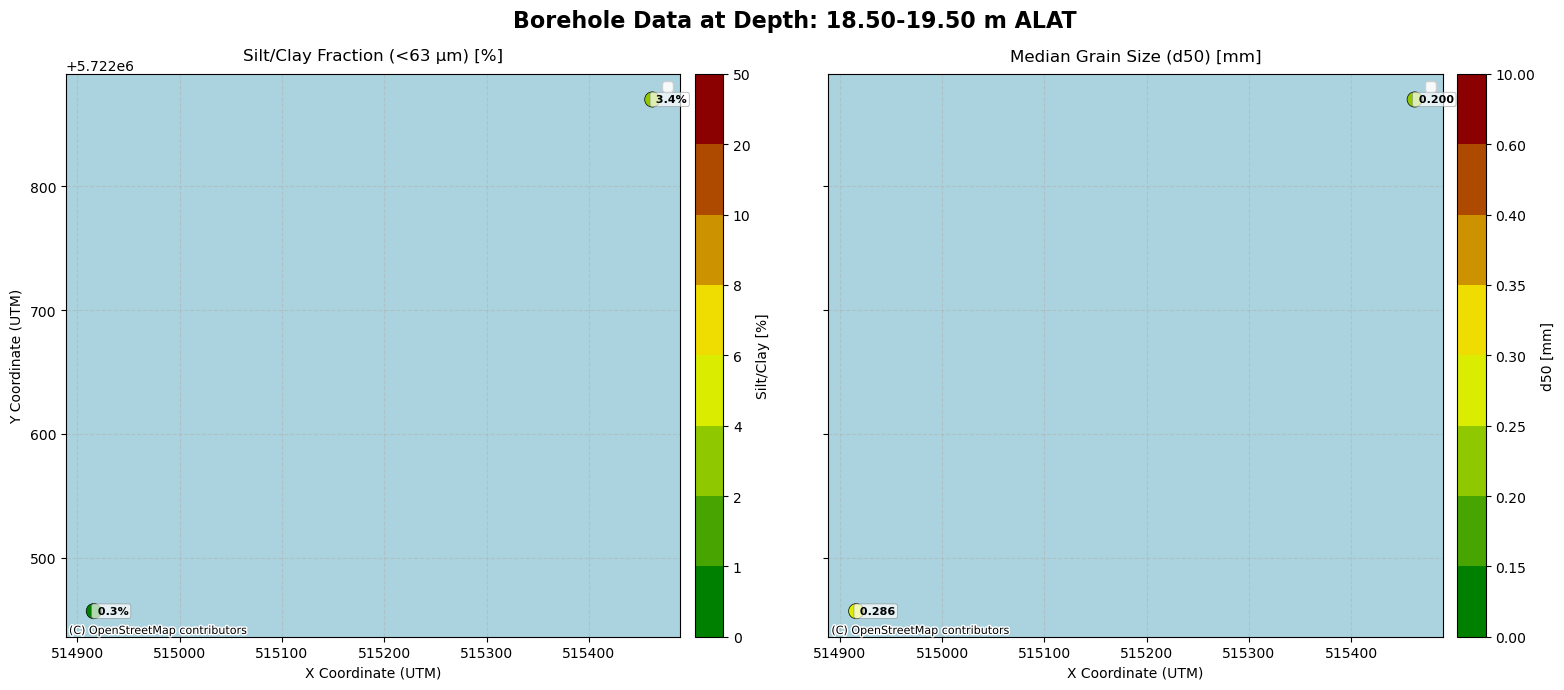

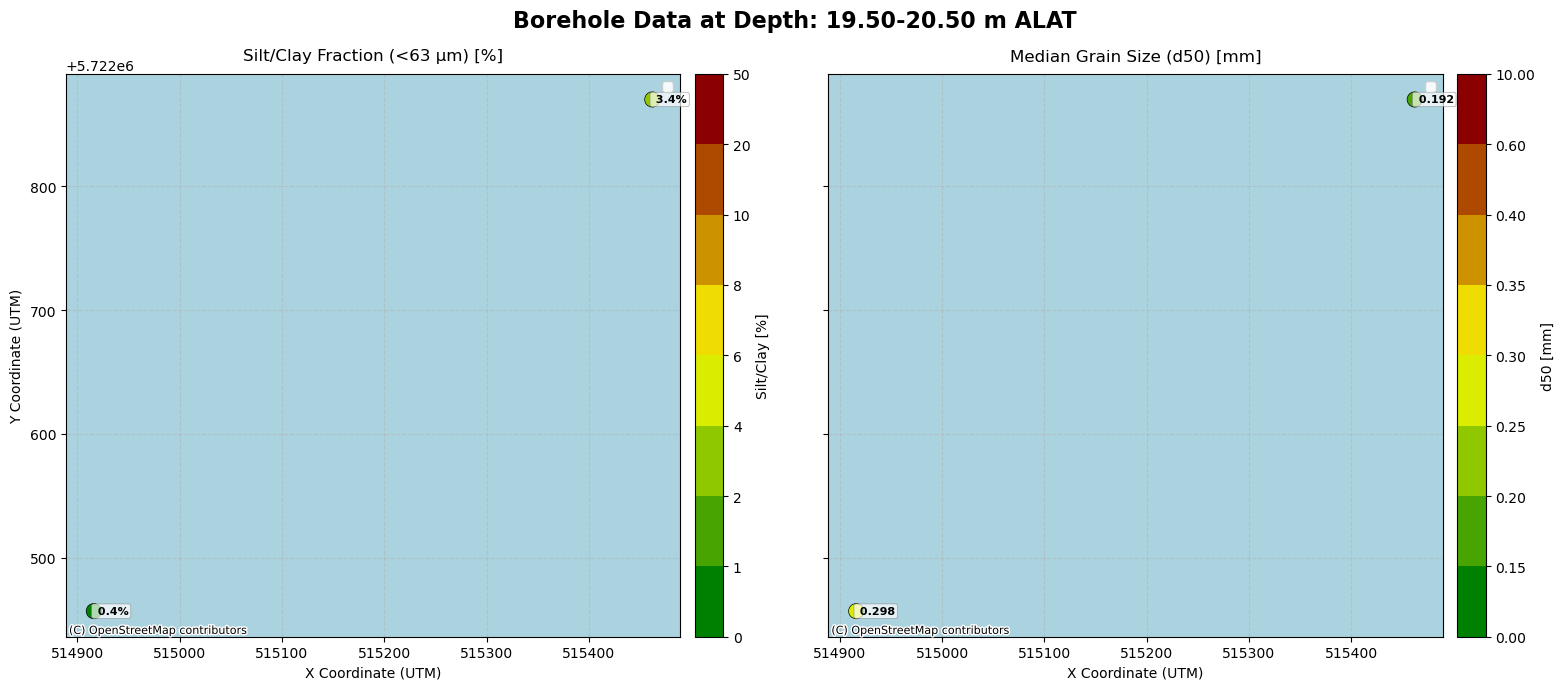

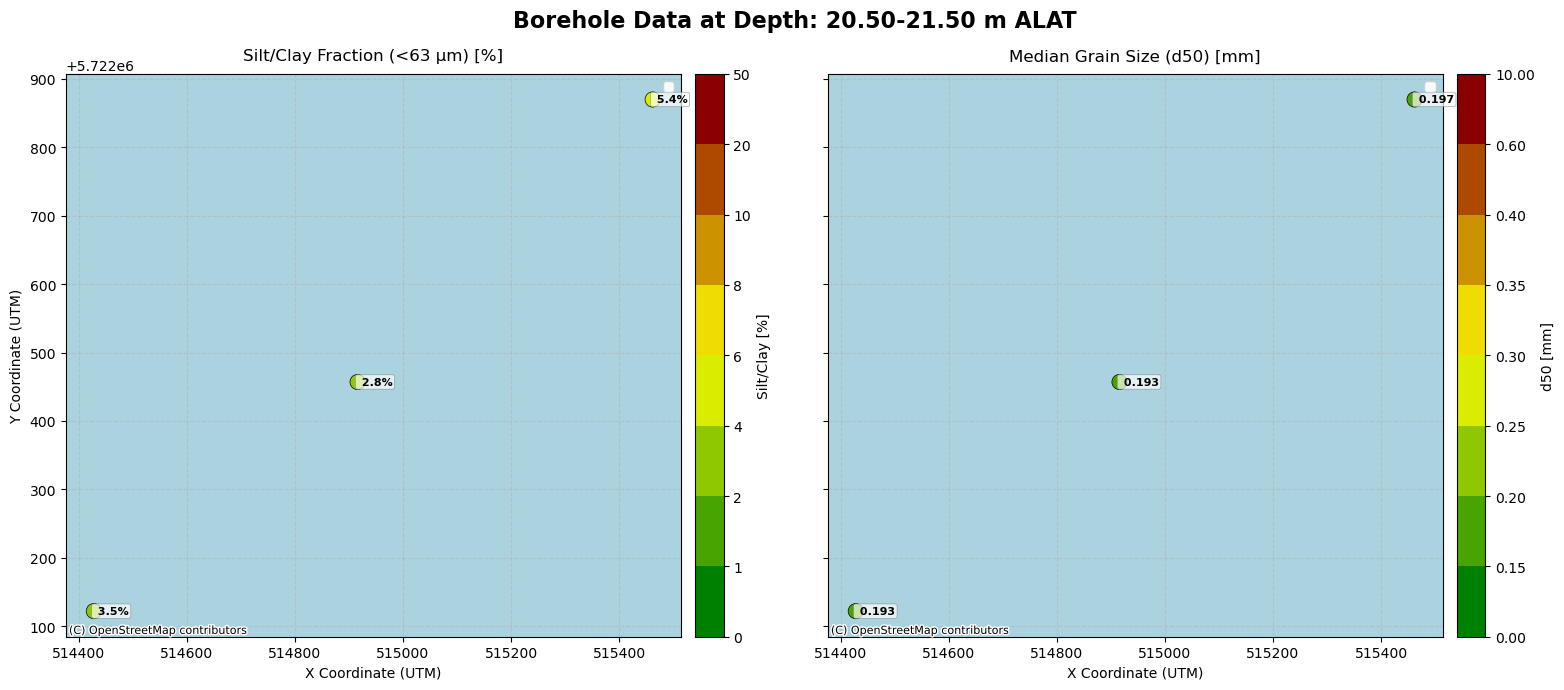

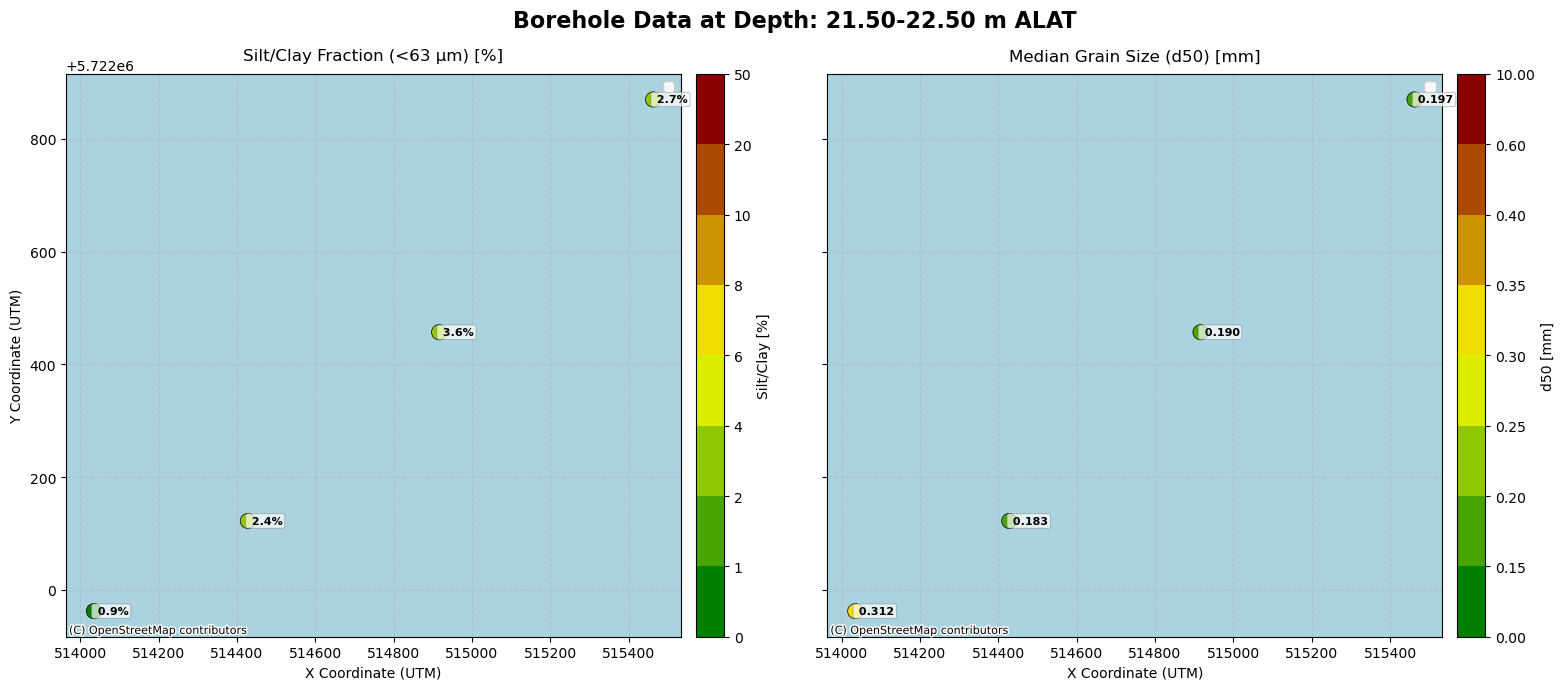

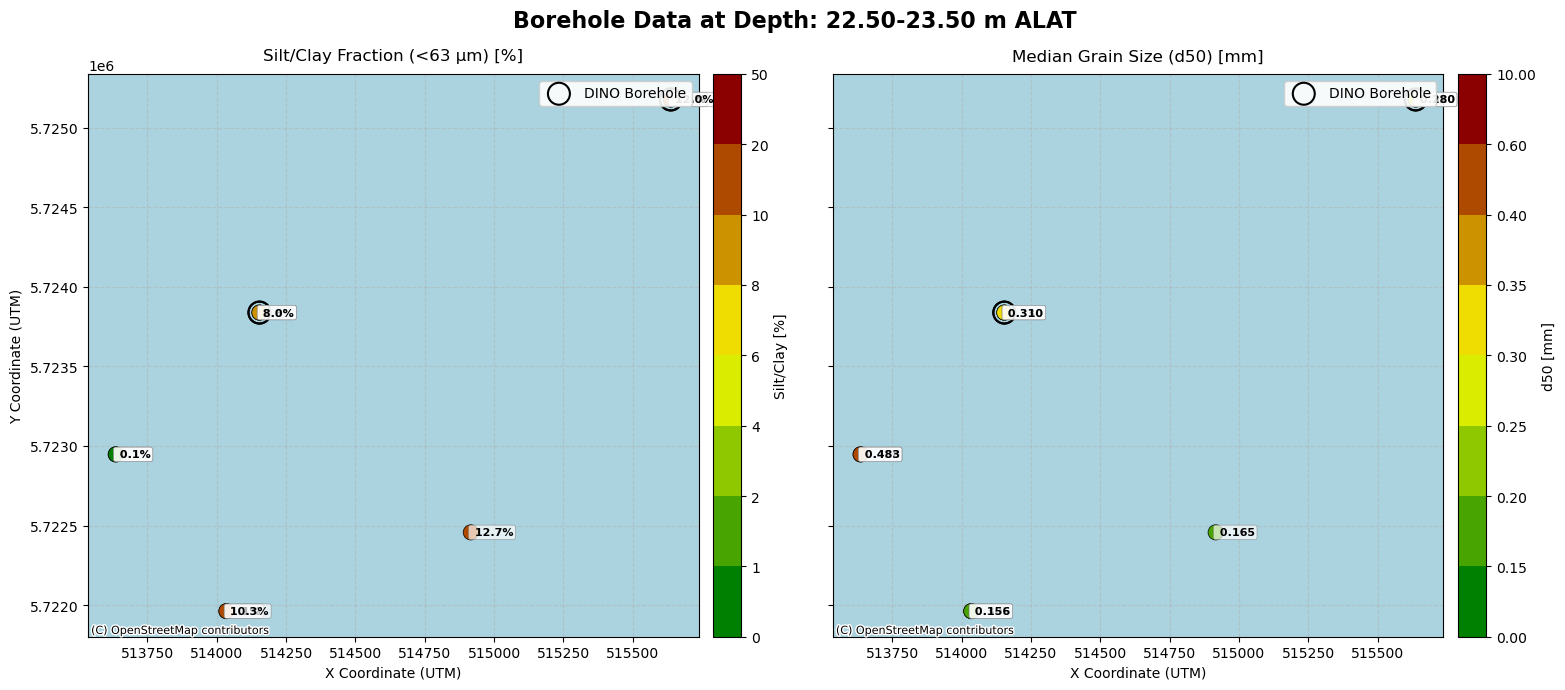

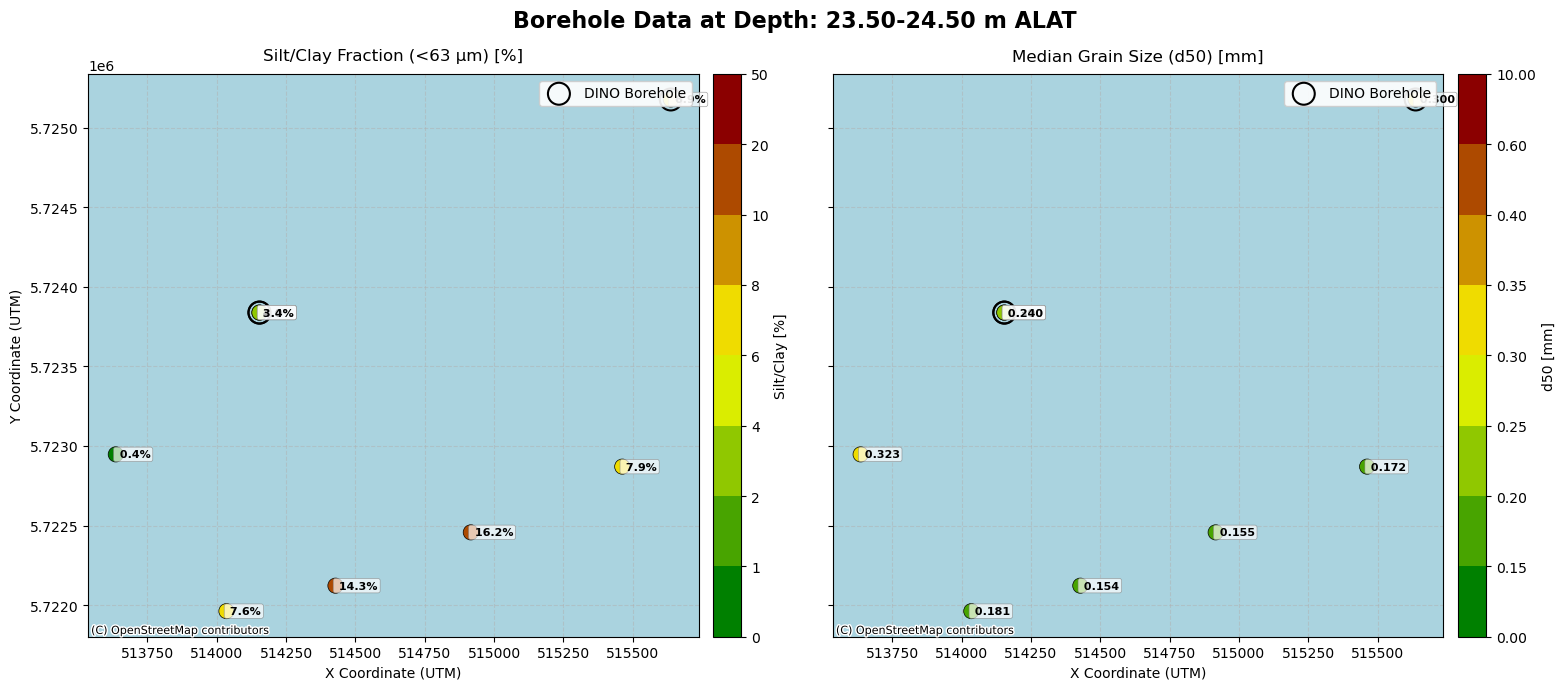

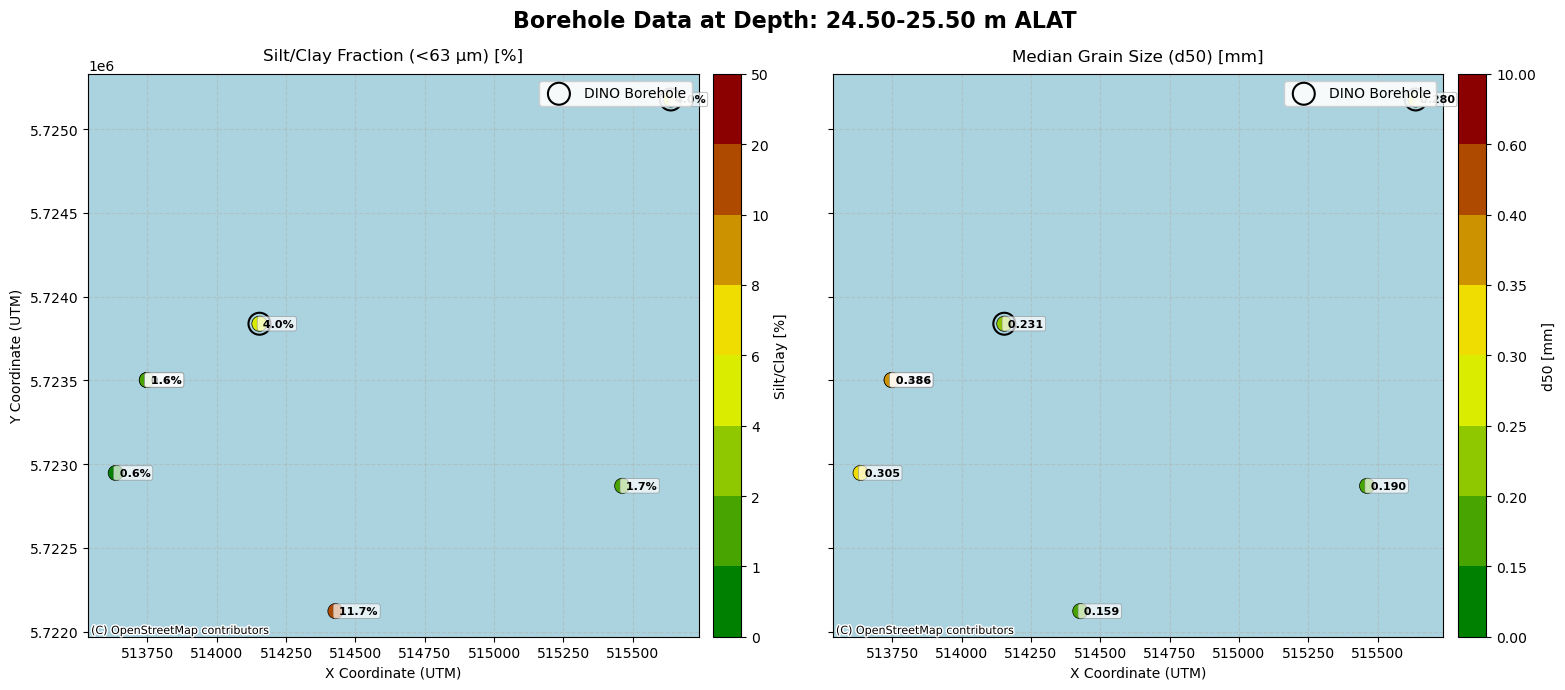

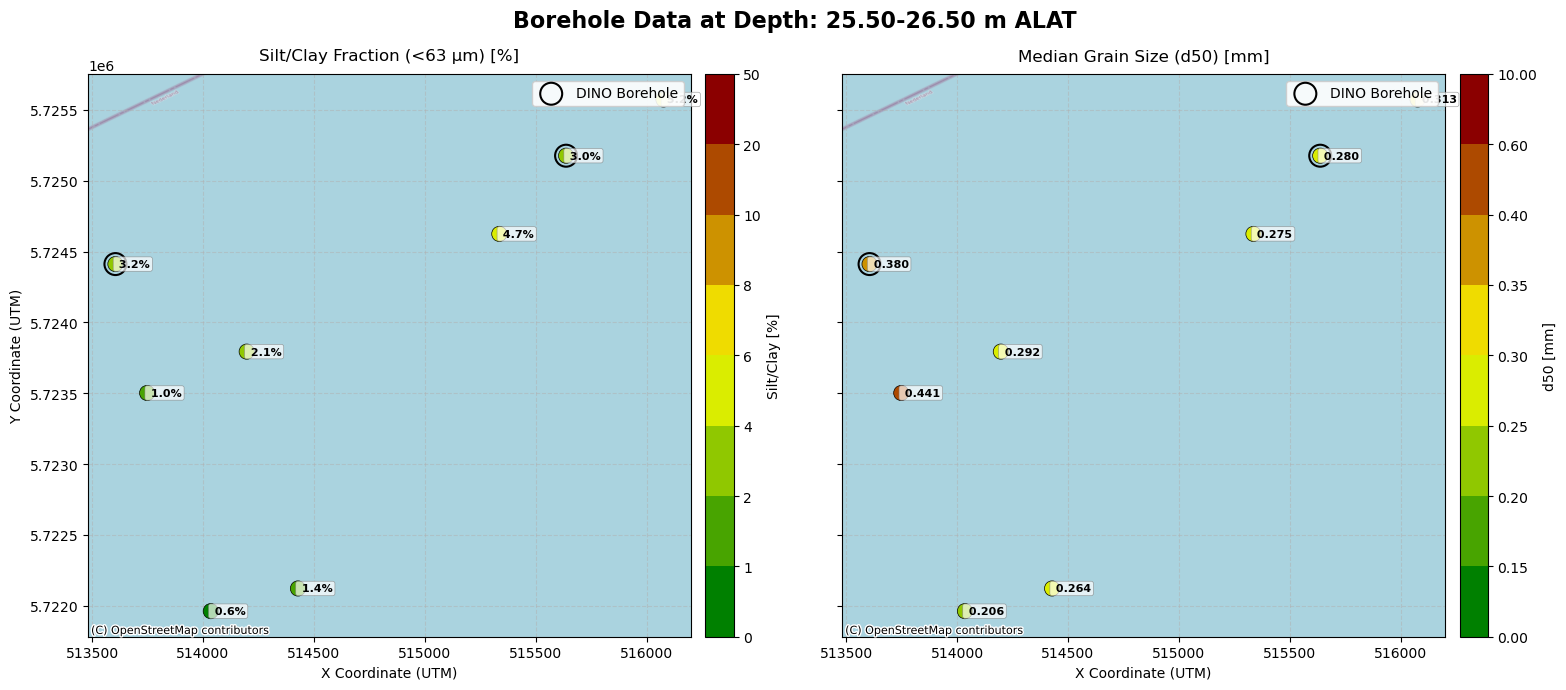

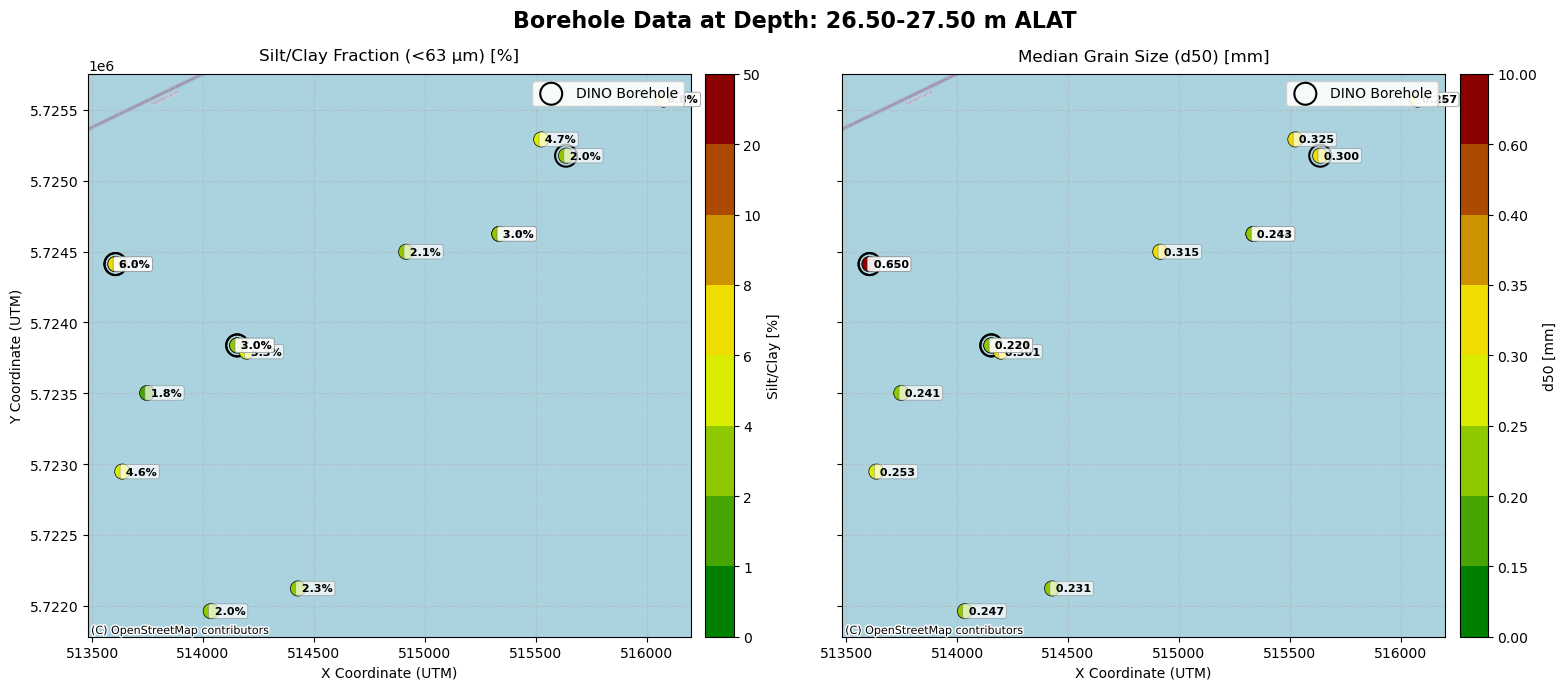

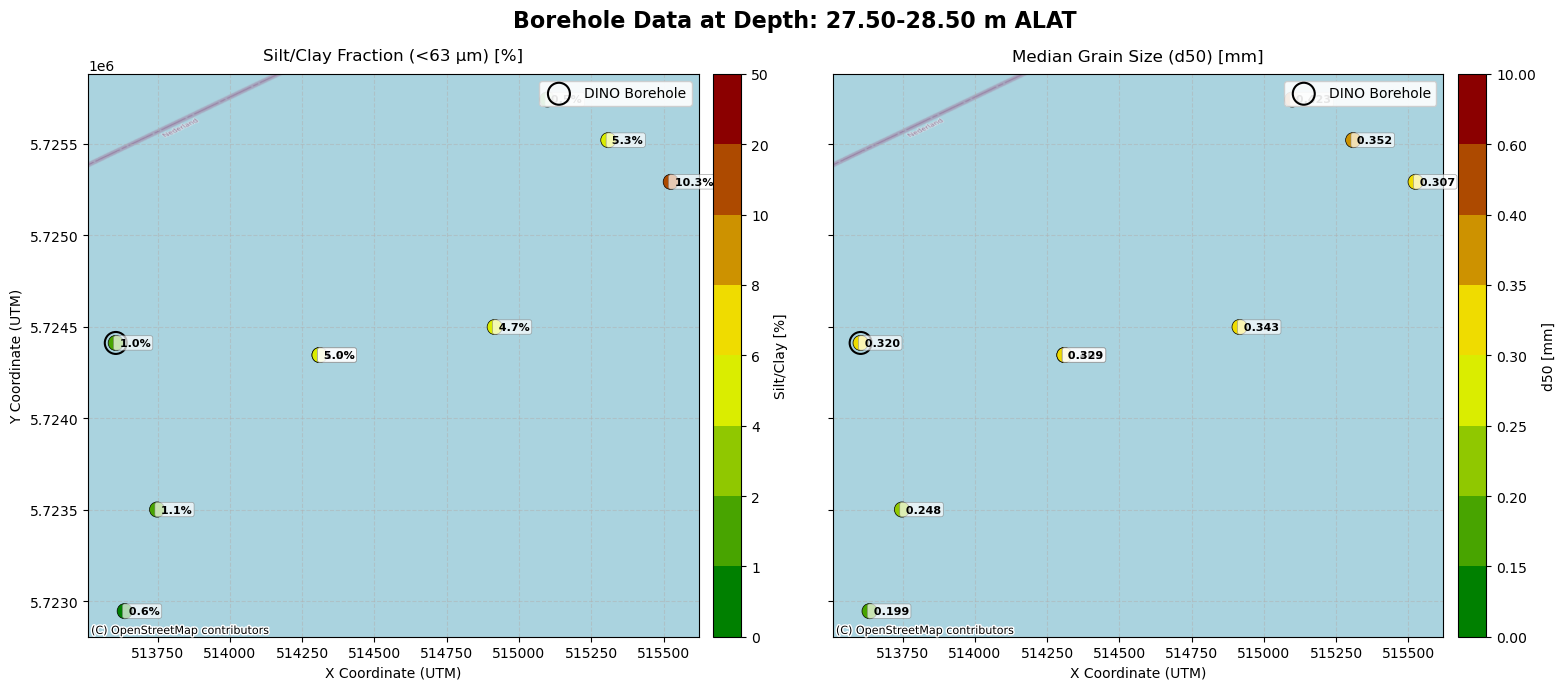

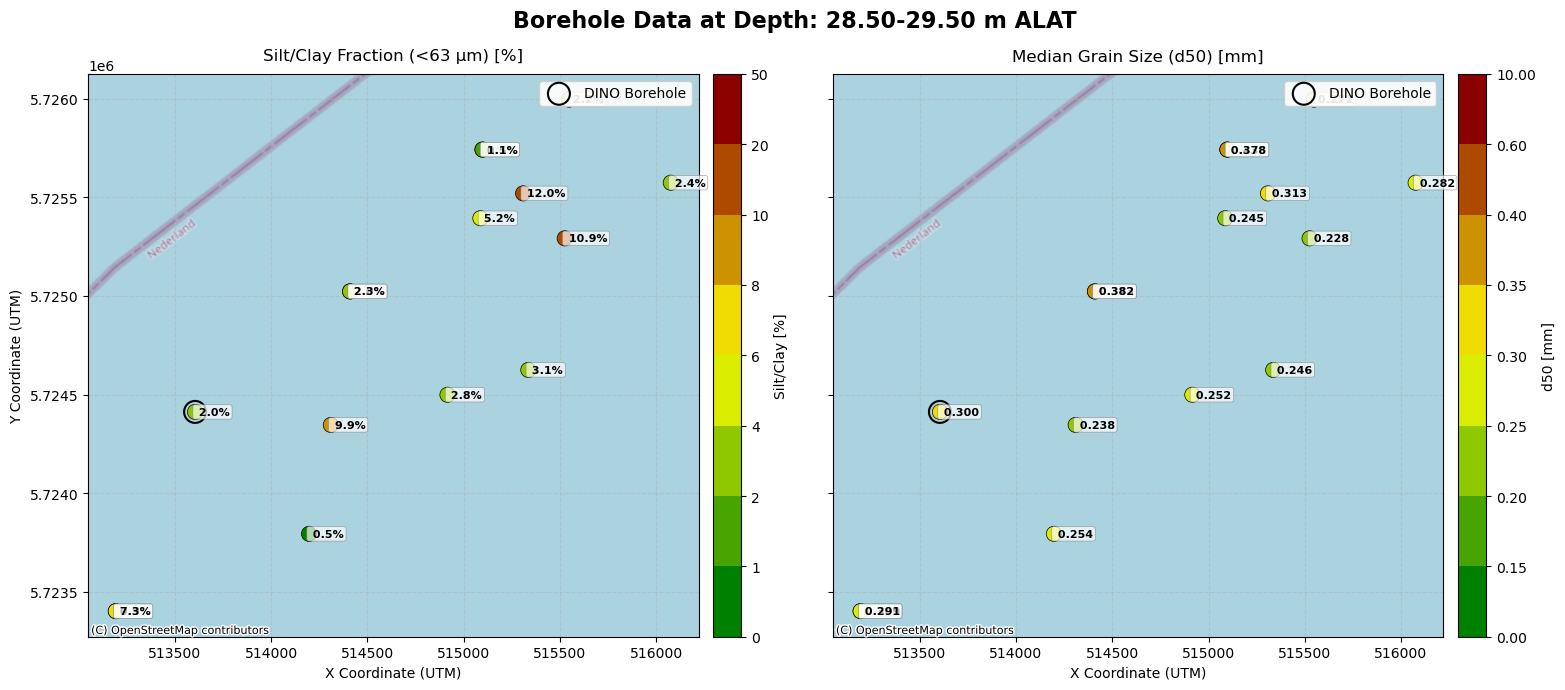

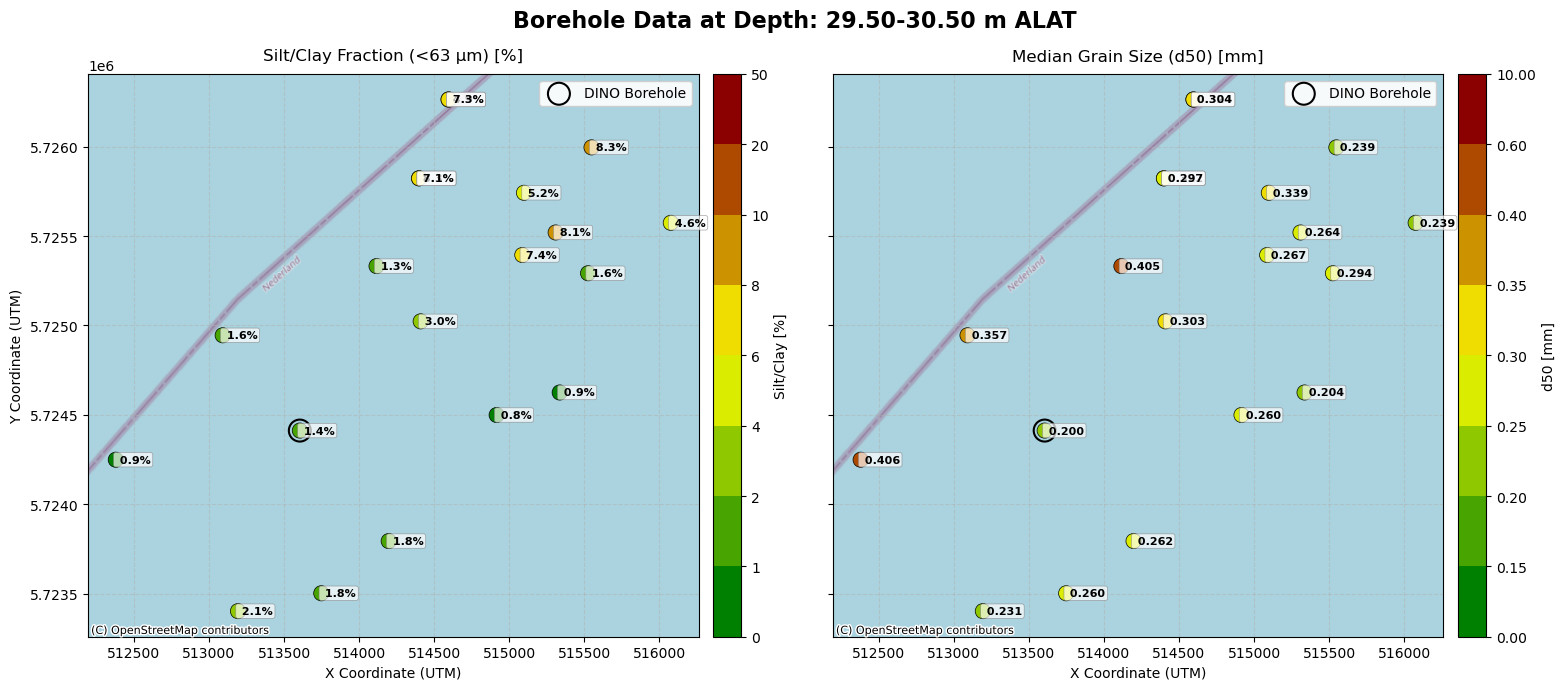

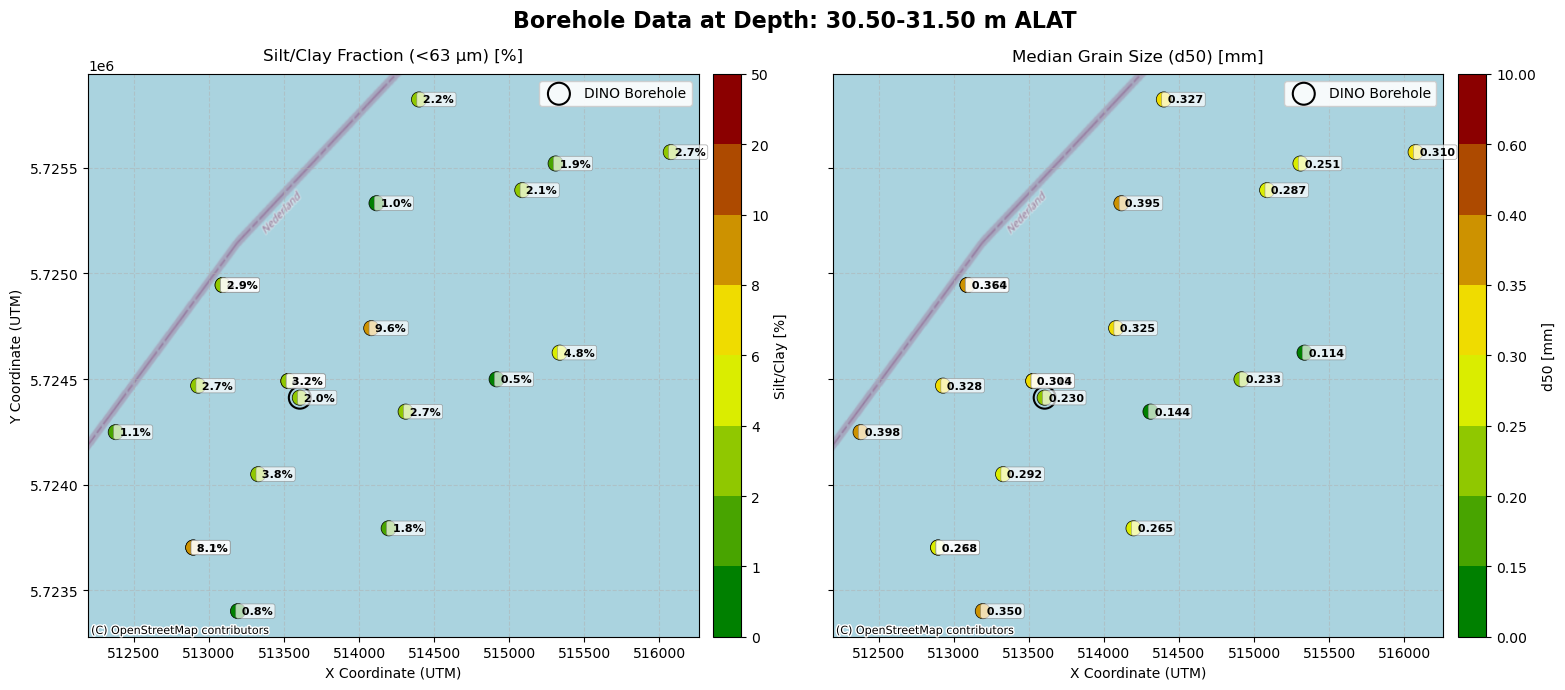

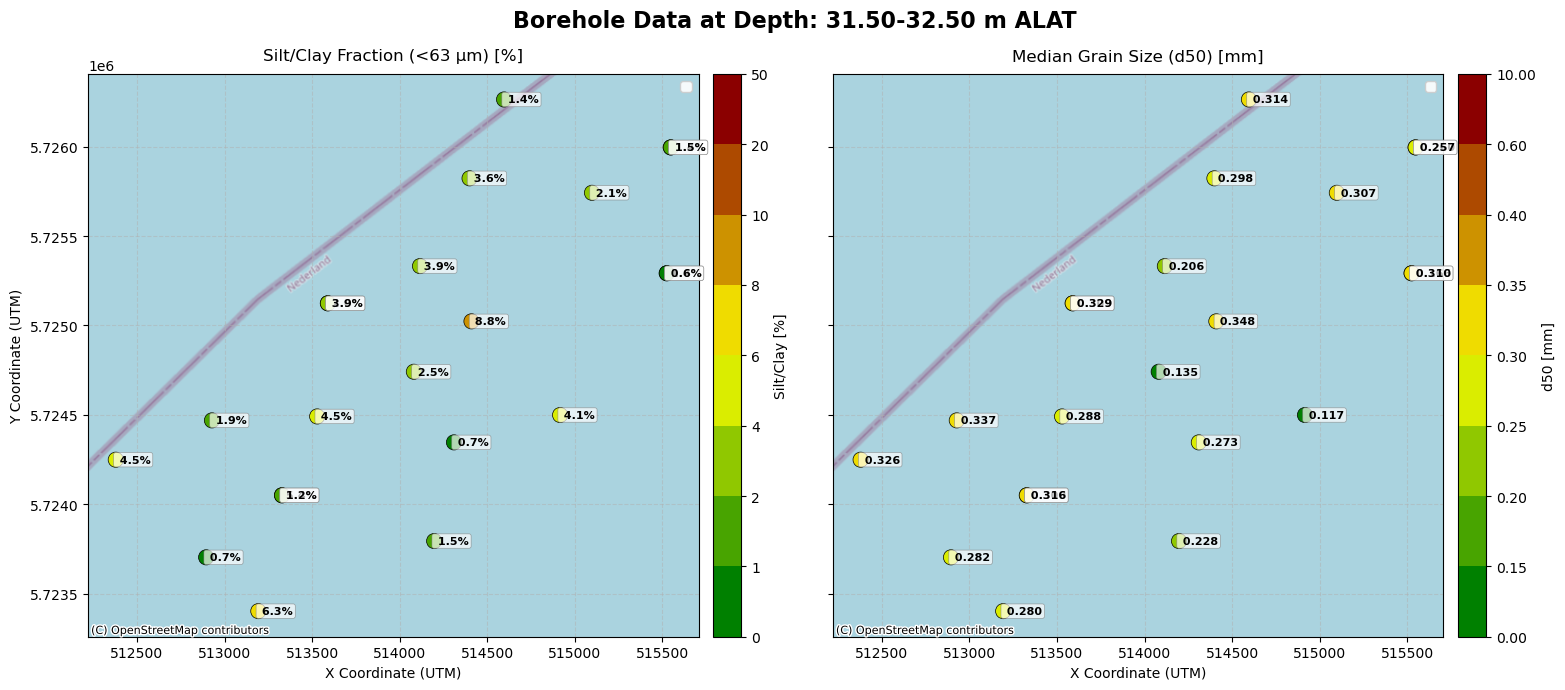

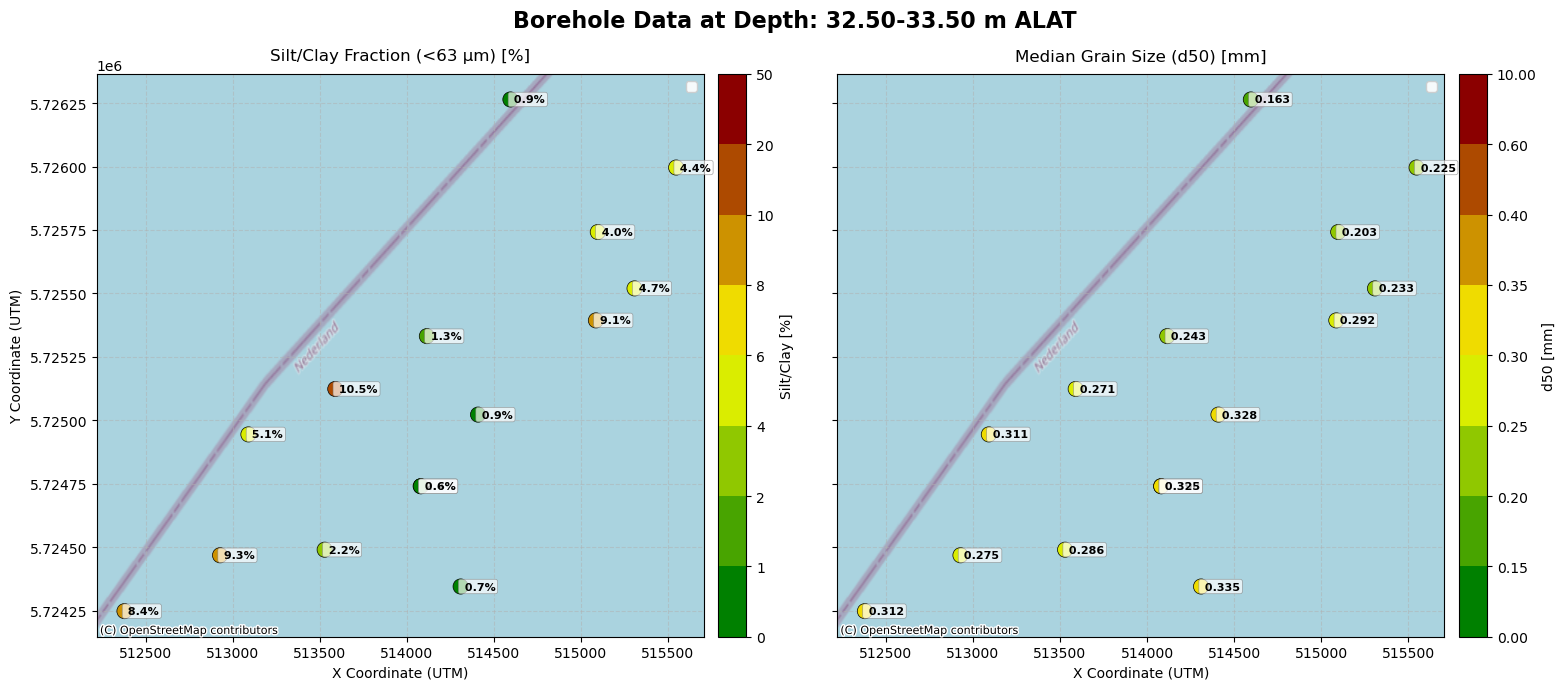

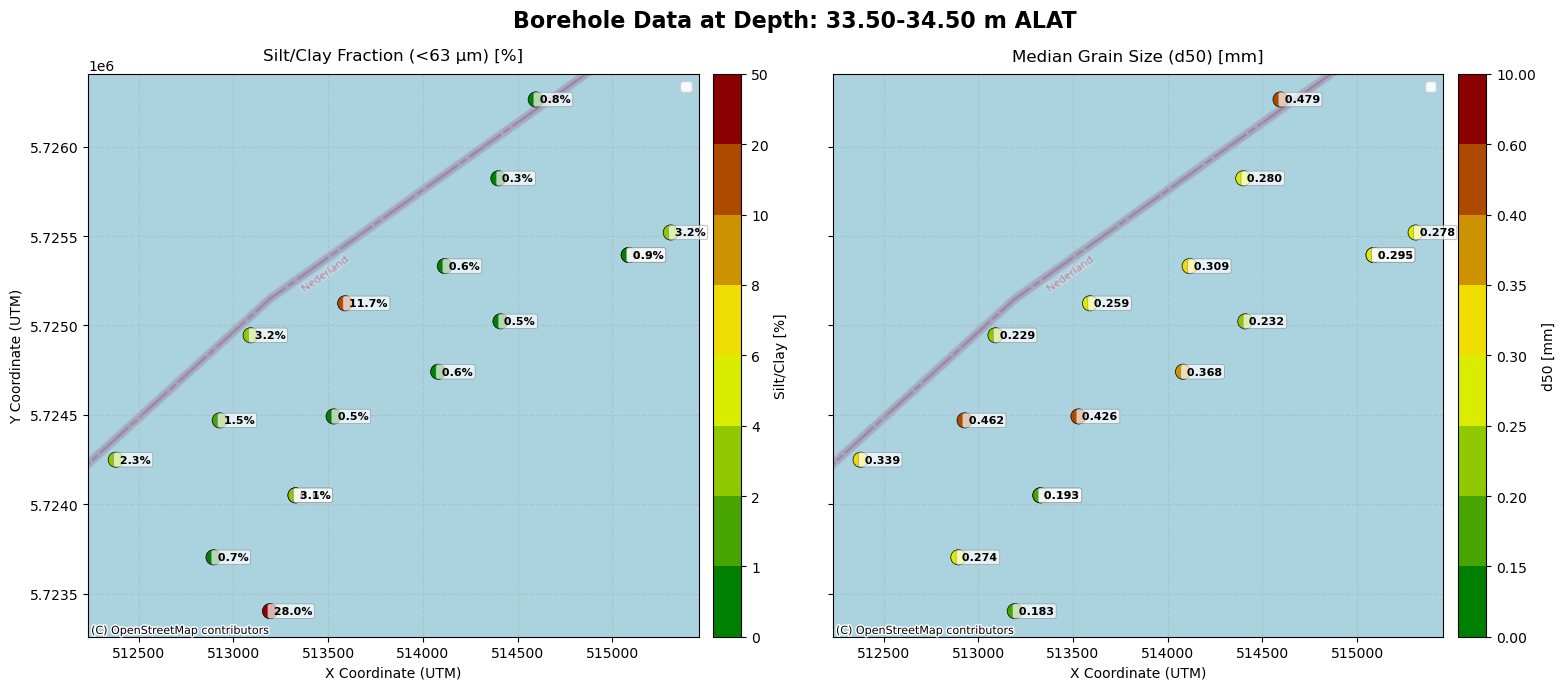

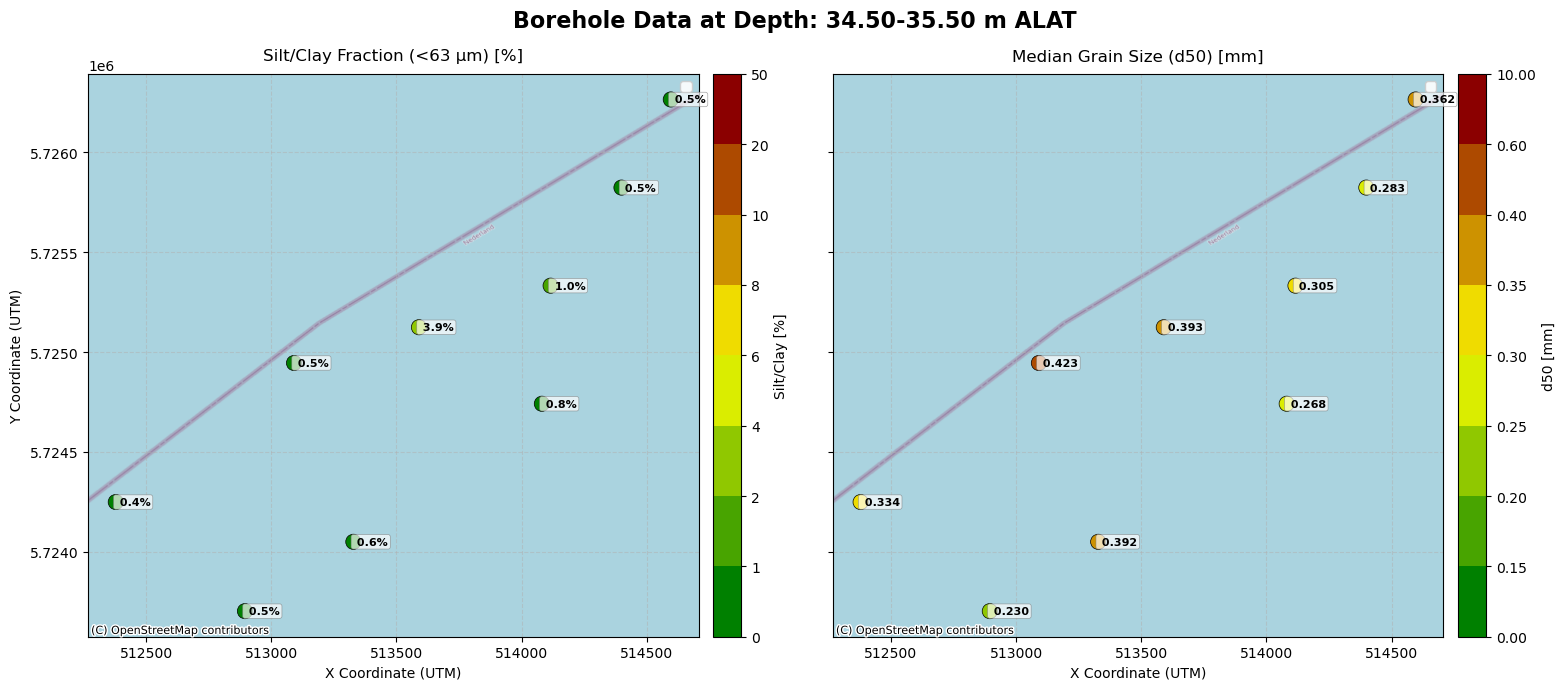

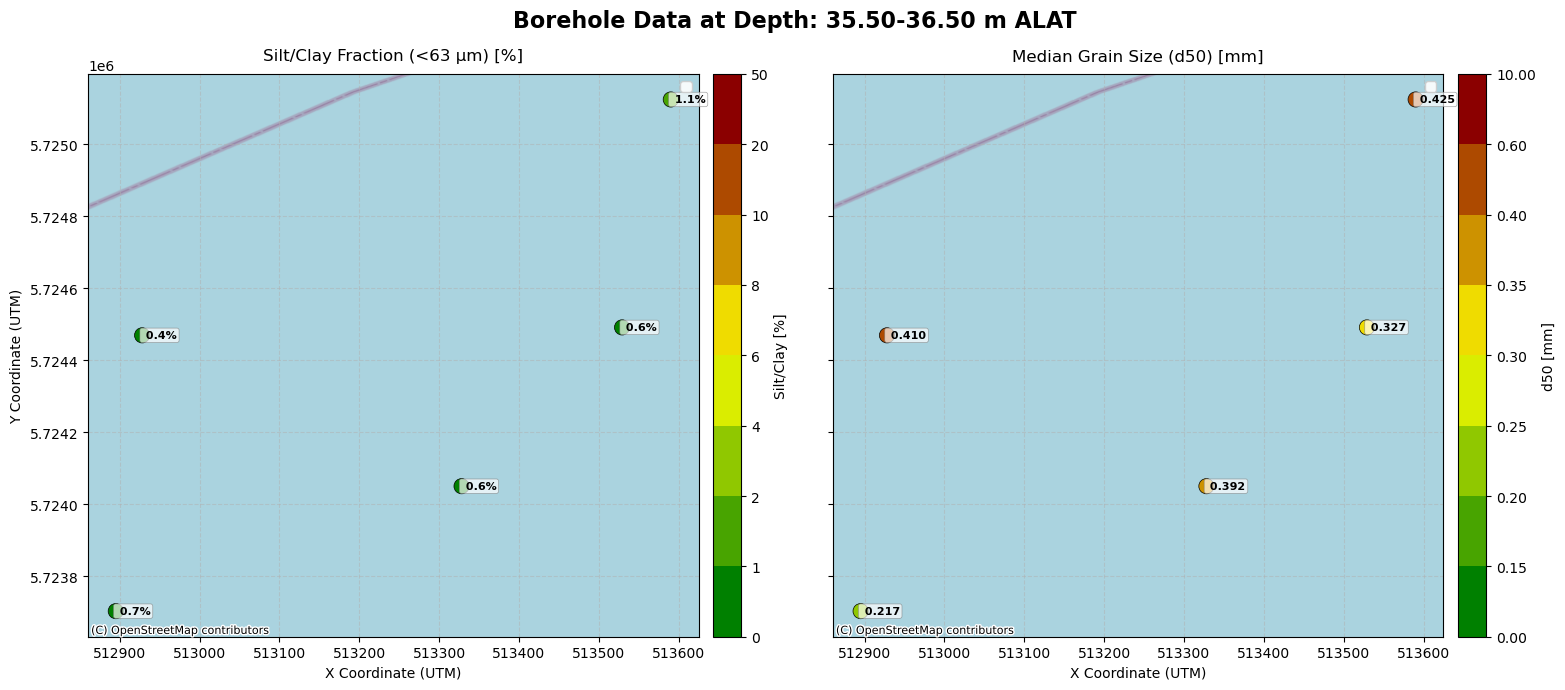

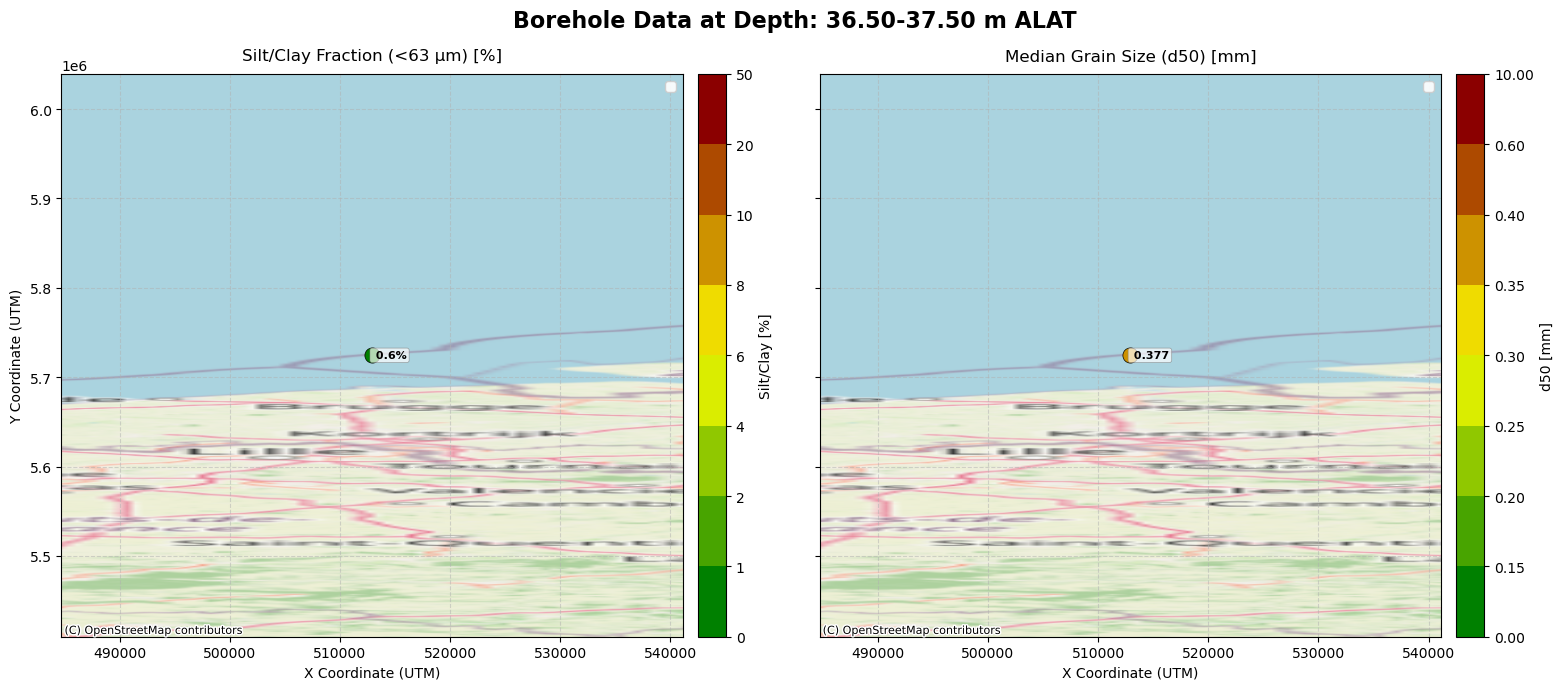

In [12]:
from matplotlib import cm
# ── SSL Patch for Windows Certificate Store Bug ──────────────────────────────
import ssl
if hasattr(ssl.SSLContext, '_load_windows_store_certs'):
    _orig_load = ssl.SSLContext._load_windows_store_certs
    def _patched_load(self, storename, purpose):
        try:
            return _orig_load(self, storename, purpose)
        except ssl.SSLError:
            pass # Ignore corrupted certificates in Windows Certificate Store
    ssl.SSLContext._load_windows_store_certs = _patched_load
# ─────────────────────────────────────────────────────────────────────────────

from pandas.core.reshape import encoding
from IPython.core import display_functions
from PIL import ExifTags
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import contextily as cx

# Define colormaps and norms
bins = [0, 1, 2, 4, 6, 8, 10, 20, 50]
colors = ["green", "yellow", "darkred"]
cmap_63 = LinearSegmentedColormap.from_list("green_to_darkred", colors)
norm_63 = mcolors.BoundaryNorm(bins, cmap_63.N)

# For d50, let's use plasma colormap with continuous norm based on data limits

bins2 = [0, .15, .2, .25, .3, .35, .4, .6, 10]

d50_min = data['d50'].min()
d50_max = data['d50'].max()
cmap_50 = LinearSegmentedColormap.from_list("green_to_darkred", colors)

#norm_d50 = mcolors.Normalize(vmin=d50_min, vmax=d50_max)
norm_d50 = mcolors.BoundaryNorm(bins2, cmap_50.N)





for i in range(len(depths)):
    depth_val = depths[i]
    # Filter data for the current depth
    sel = data[data['MID_LAT'] == depth_val].dropna(subset=['X', 'Y'])
    if len(sel) == 0:
        continue
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    fig.suptitle(f"Borehole Data at Depth: {depth_val-0.5:.2f}-{depth_val+0.5:.2f} m ALAT", fontsize=16, fontweight='bold', y=0.98)
    
    # ── Left Subplot: Silt/Clay [%] ──────────────────────────────────────────
    ax1.set_title("Silt/Clay Fraction (<63 µm) [%]", fontsize=12, pad=10)
    ax1.set_xlabel("X Coordinate (UTM)", fontsize=10)
    ax1.set_ylabel("Y Coordinate (UTM)", fontsize=10)
    
    # DINO boreholes
    dino_sel = sel[sel['DINO'] == 1]
    if len(dino_sel) > 0:
        ax1.scatter(dino_sel['X'], dino_sel['Y'], s=250, color='none', edgecolors='black', linewidths=1.5, zorder=5, label='DINO Borehole')
        
    # NaN/Missing values
    nan_sel_63 = sel[np.isnan(sel['63calculated. met zoutcorrectie'])]
    if len(nan_sel_63) > 0:
        ax1.scatter(nan_sel_63['X'], nan_sel_63['Y'], color='gray', marker='X', s=100, zorder=6, label='Missing / NaN')
        
    # Valid values heatmap
    valid_sel_63 = sel[np.isfinite(sel['63calculated. met zoutcorrectie'])]
    if len(valid_sel_63) > 0:
        heatmap1 = ax1.scatter(valid_sel_63['X'], valid_sel_63['Y'], c=valid_sel_63['63calculated. met zoutcorrectie'], 
                               cmap=cmap_63, norm=norm_63, s=120, edgecolors='black', linewidths=0.5, zorder=7)
        cbar1 = fig.colorbar(heatmap1, ax=ax1, ticks=bins, pad=0.02)
        cbar1.set_label('Silt/Clay [%]', fontsize=10)
        
        # Add labels on the points
        for _, row in valid_sel_63.iterrows():
            ax1.text(row['X'], row['Y'], f" {row['63calculated. met zoutcorrectie']:.1f}%", 
                     fontsize=8, ha='left', va='center', fontweight='semibold', zorder=8,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5, alpha=0.7))
                     
    ax1.grid(True, linestyle='--', alpha=0.5, zorder=1)
    leg1 = ax1.legend(loc='upper right', framealpha=0.9)
    if leg1:
        leg1.set_zorder(10)
    
    # ── Right Subplot: Median Grain Size d50 [mm] ────────────────────────────
    ax2.set_title("Median Grain Size (d50) [mm]", fontsize=12, pad=10)
    ax2.set_xlabel("X Coordinate (UTM)", fontsize=10)
    
    # DINO boreholes
    if len(dino_sel) > 0:
        ax2.scatter(dino_sel['X'], dino_sel['Y'], s=250, color='none', edgecolors='black', linewidths=1.5, zorder=5, label='DINO Borehole')
        
    # NaN/Missing values
    nan_sel_d50 = sel[np.isnan(sel['d50'])]
    if len(nan_sel_d50) > 0:
        ax2.scatter(nan_sel_d50['X'], nan_sel_d50['Y'], color='gray', marker='X', s=100, zorder=6, label='Missing / NaN')
        
    # Valid values heatmap
    valid_sel_d50 = sel[np.isfinite(sel['d50'])]
    if len(valid_sel_d50) > 0:
        heatmap2 = ax2.scatter(valid_sel_d50['X'], valid_sel_d50['Y'], c=valid_sel_d50['d50'], 
                               cmap=cmap_50, norm=norm_d50, s=120, edgecolors='black', linewidths=0.5, zorder=7)
        cbar2 = fig.colorbar(heatmap2, ax=ax2, pad=0.02)
        cbar2.set_label('d50 [mm]', fontsize=10)
        
        # Add labels on the points
        for _, row in valid_sel_d50.iterrows():
            ax2.text(row['X'], row['Y'], f" {row['d50']:.3f}", 
                     fontsize=8, ha='left', va='center', fontweight='semibold', zorder=8,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5, alpha=0.7))
                     
    ax2.grid(True, linestyle='--', alpha=0.5, zorder=1)
    leg2 = ax2.legend(loc='upper right', framealpha=0.9)
    if leg2:
        leg2.set_zorder(10)
    
    # Store original limits before adding basemap
    xlim = ax1.get_xlim()
    ylim = ax1.get_ylim()
    
    # Add basemap from OpenStreetMaps
    try:
        cx.add_basemap(ax1, crs="EPSG:32631", source=cx.providers.OpenStreetMap.Mapnik, zorder=0)
        cx.add_basemap(ax2, crs="EPSG:32631", source=cx.providers.OpenStreetMap.Mapnik, zorder=0)
    except Exception as e:
        print(f"Warning: could not add basemap: {e}")
        
    # Restore original limits
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    
    plt.tight_layout()
    plt.show()